# Comparator Atlas: When Calibration Is Not Enough

**Wei-Lun Hsu — National Tsing Hua University**

IEEE SSCS Code-a-Chip, ISSCC 2027 — open-source circuit-design and
characterization study. Original project license: MIT.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sscs-ose/sscs-ose-code-a-chip.github.io/blob/main/ISSCC27/submitted_notebooks/comparator_atlas/Comparator_Atlas.ipynb)

**Abstract.** A small switching-boundary offset does not guarantee a
valid decision before a deadline. This notebook studies that distinction
using unmodified SKY130 device models, a bounded nine-circuit search,
a 49-condition original-versus-selected comparison, and a subsequently
declared lower-energy control. It distinguishes wrong decisions,
unresolved outputs, unavailable calibration, and numerical sensitivity.
A corrected evidence table, actual saved waveforms, source hashes, and
independent live-SPICE instructions make the analysis inspectable.

**Scope.** These are pre-layout deterministic simulations, not silicon,
foundry yield, a new StrongARM topology, or a globally optimal design.
Energy means the measured core VDD rail, excluding the input/clock
drivers and calibration controller. The lower-energy comparison is
explicitly post-selection, not a newly blinded benchmark.

**Reproduction modes.** Default execution verifies the supplied evidence
and recomputes plots and waveform metrics without a circuit simulator.
Optional live simulation and the full campaign are separate switches
below. Python 3.10 is supported for the organizer's notebook runner.
A fresh complete SPICE campaign can take hours; it is not an implicit
side effect of opening this notebook.

In [1]:
from pathlib import Path
import importlib.util
from importlib import metadata
import subprocess
import sys

parts = (
    "ISSCC27", "submitted_notebooks", "comparator_atlas"
)
candidates = [Path.cwd(), Path.cwd().joinpath(*parts)]
entry_root = next(
    (p for p in candidates if (p / "entry_tools.py").is_file()),
    None,
)
if entry_root is None:
    source = Path.cwd() / "comparator-atlas-source"
    if source.exists():
        raise RuntimeError(
            "An incomplete source directory already exists. "
            "Inspect it before retrying; it was not overwritten."
        )
    repository = (
        "https://github.com/WLHsu0827/"
        "sscs-ose-code-a-chip.github.io.git"
    )
    branch = "wlhsu0827-comparator-atlas-isscc27"
    subprocess.run(
        [
            "git", "clone", "--quiet", "--depth", "1",
            "--filter=blob:none", "--no-checkout",
            "--single-branch", "--branch", branch,
            repository, str(source),
        ],
        check=True,
    )
    subprocess.run(
        [
            "git", "-C", str(source), "sparse-checkout",
            "set", str(Path(*parts)),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(source), "checkout", "--quiet", branch],
        check=True,
    )
    entry_root = source.joinpath(*parts)
    if not (entry_root / "entry_tools.py").is_file():
        raise RuntimeError("The downloaded entry is incomplete.")
required = {
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "matplotlib": "3.10.3",
    "nbformat": "5.10.4",
    "ipywidgets": "8.1.7",
}
needs_setup = []
for name, version in required.items():
    if importlib.util.find_spec(name) is None:
        needs_setup.append(name)
    elif metadata.version(name) != version:
        needs_setup.append(name)
if needs_setup:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "-r", str(entry_root / "requirements-review.txt"),
        ],
        check=True,
    )
stale = []
for name, version in required.items():
    loaded = sys.modules.get(name)
    if loaded is not None:
        loaded_version = getattr(loaded, "__version__", version)
        if loaded_version != version:
            stale.append(name)
if stale:
    raise RuntimeError(
        "Dependencies were updated but older packages are loaded. "
        "Restart the kernel/runtime once, then Run all."
    )
sys.path.insert(0, str(entry_root))
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Code, display
import entry_tools as entry

%matplotlib inline
RUN_LIVE_SPICE = False
RUN_FULL_CAMPAIGN = False
print("Python:", sys.version.split()[0])
print("Default: verified supplied evidence, not a fresh SPICE run.")

Python: 3.10.18
Default: verified supplied evidence, not a fresh SPICE run.


## 1. State a falsifiable decision contract

At deadline $T$ after the evaluation clock midpoint, the decision is
valid only if **both** complementary outputs reach their assigned
rails: one at least $0.8V_{\mathrm{DD}}$, the other at most
$0.2V_{\mathrm{DD}}$. Its sign must equal that of the externally
applied differential input. A resolved opposite sign is **wrong**;
a missing complementary-rail decision is **unresolved**.
Zero input is not counted in pass fractions.

The sampled decision time excludes an early output glitch: it is the
first saved valid sample after the final invalid sample, through the
reporting deadline. A 1 ns decision deadline does not mean that a
1 GHz clock was tested; the clock period is 10 ns.

$$E_{\mathrm{core}}=-V_{\mathrm{DD}}
\int_{20\,\mathrm{ns}}^{30\,\mathrm{ns}} I_{V_{\mathrm{DD}}}(t)\,dt.$$

The full third cycle includes reset. Two previous cycles provide
warmup. Input common mode is half the supply, clock edges are 50 ps,
and each output carries a 5 fF ideal load unless an explicitly named
interface stress changes that condition.

Simulator errors, failed reset, missing waveforms, corrupt archives
and unavailable calibration are not successful circuit results.
All reported fractions refer to a finite declared grid, not yield
or an input-probability distribution.

## 2. Calibration must preserve unresolved intervals

A zero-input trim scan locates candidates near a sign change. Input
bisection then brackets confirmed opposite decisions. The score is

$$M_T=\max(|v_-(T)|,\ |v_+(T)|).$$

The midpoint of a wide unresolved interval is not evidence of a
precisely known zero offset. The host search minimizes the larger
absolute endpoint among measured candidates, with 0.2 mV input-bracket
resolution. This is a documented heuristic around an assumed locally
monotonic noiseless transfer, not a new calibration algorithm or proof
of a global optimum.

The long-deadline policy uses 3.5 ns; a separate ablation applies the
same procedure at 1 ns. A TT/1.8 V/27 C reference-code policy transfers
a single code across model corners. It is **not** a per-die factory
calibration at an unknown fixed process corner.

## 3. Physical circuit family and a frozen selection rule

The conventional StrongARM core has eleven transistor instances,
including four reset PFETs. Each trim magnitude bit adds one auxiliary
analog input NFET and its digital source-gating NFET on each side.
The selected circuit has 27 instances and **four magnitude bits plus
sign**, supporting codes -15 through +15. An on-chip decoder and
calibration controller are not implemented.

The auxiliary analog gates track their respective input. No ideal
source simply subtracts a fitted offset. All trim devices remain
physically present at code zero; comparison within a design therefore
retains its trim parasitic loading.

Nine candidates vary device threshold flavor, dimensions and trim
range. LVT applies to the main and auxiliary analog input paths;
latch, tail and digital switches remain standard-VT.

Selection used three PVT conditions and six inputs, with 2x mean
training core-energy and 4x gate-area-proxy budgets. The ranking
maximizes worst-case training coverage, then mean coverage, followed
by boundary magnitude, energy and gate geometry. The gate-area proxy
is the sum of transistor W times L, not placed/routed area.
The first prototype informed the family. All rejected candidates
remain visible in the recorded selection.

In [2]:
if RUN_FULL_CAMPAIGN:
    entry.full_reproduction()
evidence = entry.load_evidence()
selection = evidence["selection"]
candidates = pd.DataFrame([
    {
        "design": item["design"]["name"],
        "input_device": item["design"]["input_device"],
        "transistors": item["design"]["transistor_count"],
        "gate_area_um2": item["design"]["gate_area_proxy_um2"],
        "worst_training_coverage":
            item["worst_case_correct_fraction"],
        "mean_training_core_fj": item["mean_core_energy_fj"],
        "eligible": item["eligible"],
    }
    for item in selection["candidates"]
])
display(candidates)
print("Frozen selected design:", selection["selected_design"])
display(Code(
    (entry.STUDY / "selected_circuit.spice").read_text(),
    language="spice",
))

,design,input_device,transistors,gate_area_um2,worst_training_coverage,mean_training_core_fj,eligible
0,baseline,nfet_01v8,23,10.83,0.000000,141.994479,True
1,svt_fast_4b,nfet_01v8,27,22.20,0.000000,267.328362,True
2,lvt_base_3b,nfet_01v8_lvt,23,10.83,0.833333,160.380620,True
3,lvt_fine_3b,nfet_01v8_lvt,23,16.71,0.666667,196.648509,True
4,lvt_balanced_4b,nfet_01v8_lvt,27,20.55,0.833333,257.144356,True
5,lvt_fine_4b,nfet_01v8_lvt,27,33.15,0.833333,330.052380,False
6,lvt_fast_4b,nfet_01v8_lvt,27,22.20,0.833333,295.022182,False
7,lvt_fast_fine_4b,nfet_01v8_lvt,27,34.80,0.833333,367.560860,False
8,lvt_wide_5b,nfet_01v8_lvt,31,41.64,0.666667,496.946536,False


Frozen selected design: lvt_balanced_4b


* Comparator Atlas declared design: lvt_balanced_4b
* Generated physical transistor netlist. Gate-area proxy is not layout area.
.subckt atlas vinp vinn clk vdd vss qp qn tp0 tp1 tp2 tp3 tn0 tn1 tn2 tn3
+ params: pair_skew=0
Xinp xp vinp tail vss sky130_fd_pr__nfet_01v8_lvt
+ w={3*(1+pair_skew)} l=0.15
+ ad={0.29*(3*(1+pair_skew))} as={0.29*(3*(1+pair_skew))}
+ pd={2*(0.29+(3*(1+pair_skew)))} ps={2*(0.29+(3*(1+pair_skew)))}
Xinn xn vinn tail vss sky130_fd_pr__nfet_01v8_lvt
+ w={3*(1-pair_skew)} l=0.15
+ ad={0.29*(3*(1-pair_skew))} as={0.29*(3*(1-pair_skew))}
+ pd={2*(0.29+(3*(1-pair_skew)))} ps={2*(0.29+(3*(1-pair_skew)))}
Xtail tail clk vss vss sky130_fd_pr__nfet_01v8
+ w={7} l=0.15
+ ad={0.29*(7)} as={0.29*(7)}
+ pd={2*(0.29+(7))} ps={2*(0.29+(7))}
Xln qn qp xp vss sky130_fd_pr__nfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xlp qp qn xn vss sky130_fd_pr__nfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xpn qn qp vdd vdd sky130_fd_pr__pfet_01v8
+ w={2} l=0.15
+ ad={0.29*(2)} as={0.29*(2)}
+ pd={2*(0.29+(2))} ps={2*(0.29+(2))}
Xpp qp qn vdd vdd sky130_fd_pr__pfet_01v8
+ w={2} l=0.15
+ ad={0.29*(2)} as={0.29*(2)}
+ pd={2*(0.29+(2))} ps={2*(0.29+(2))}
Xrxp xp clk vdd vdd sky130_fd_pr__pfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xrxn xn clk vdd vdd sky130_fd_pr__pfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xrqp qp clk vdd vdd sky130_fd_pr__pfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xrqn qn clk vdd vdd sky130_fd_pr__pfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xtp0 xp vinp sp0 vss sky130_fd_pr__nfet_01v8_lvt
+ w={0.42} l=1
+ ad={0.29*(0.42)} as={0.29*(0.42)}
+ pd={2*(0.29+(0.42))} ps={2*(0.29+(0.42))}
Xsp0 sp0 tp0 tail vss sky130_fd_pr__nfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xtp1 xp vinp sp1 vss sky130_fd_pr__nfet_01v8_lvt
+ w={0.84} l=1
+ ad={0.29*(0.84)} as={0.29*(0.84)}
+ pd={2*(0.29+(0.84))} ps={2*(0.29+(0.84))}
Xsp1 sp1 tp1 tail vss sky130_fd_pr__nfet_01v8
+ w={2} l=0.15
+ ad={0.29*(2)} as={0.29*(2)}
+ pd={2*(0.29+(2))} ps={2*(0.29+(2))}
Xtp2 xp vinp sp2 vss sky130_fd_pr__nfet_01v8_lvt
+ w={1.68} l=1
+ ad={0.29*(1.68)} as={0.29*(1.68)}
+ pd={2*(0.29+(1.68))} ps={2*(0.29+(1.68))}
Xsp2 sp2 tp2 tail vss sky130_fd_pr__nfet_01v8
+ w={4} l=0.15
+ ad={0.29*(4)} as={0.29*(4)}
+ pd={2*(0.29+(4))} ps={2*(0.29+(4))}
Xtp3 xp vinp sp3 vss sky130_fd_pr__nfet_01v8_lvt
+ w={3.36} l=1
+ ad={0.29*(3.36)} as={0.29*(3.36)}
+ pd={2*(0.29+(3.36))} ps={2*(0.29+(3.36))}
Xsp3 sp3 tp3 tail vss sky130_fd_pr__nfet_01v8
+ w={8} l=0.15
+ ad={0.29*(8)} as={0.29*(8)}
+ pd={2*(0.29+(8))} ps={2*(0.29+(8))}
Xtn0 xn vinn sn0 vss sky130_fd_pr__nfet_01v8_lvt
+ w={0.42} l=1
+ ad={0.29*(0.42)} as={0.29*(0.42)}
+ pd={2*(0.29+(0.42))} ps={2*(0.29+(0.42))}
Xsn0 sn0 tn0 tail vss sky130_fd_pr__nfet_01v8
+ w={1} l=0.15
+ ad={0.29*(1)} as={0.29*(1)}
+ pd={2*(0.29+(1))} ps={2*(0.29+(1))}
Xtn1 xn vinn sn1 vss sky130_fd_pr__nfet_01v8_lvt
+ w={0.84} l=1
+ ad={0.29*(0.84)} as={0.29*(0.84)}
+ pd={2*(0.29+(0.84))} ps={2*(0.29+(0.84))}
Xsn1 sn1 tn1 tail vss sky130_fd_pr__nfet_01v8
+ w={2} l=0.15
+ ad={0.29*(2)} as={0.29*(2)}
+ pd={2*(0.29+(2))} ps={2*(0.29+(2))}
Xtn2 xn vinn sn2 vss sky130_fd_pr__nfet_01v8_lvt
+ w={1.68} l=1
+ ad={0.29*(1.68)} as={0.29*(1.68)}
+ pd={2*(0.29+(1.68))} ps={2*(0.29+(1.68))}
Xsn2 sn2 tn2 tail vss sky130_fd_pr__nfet_01v8
+ w={4} l=0.15
+ ad={0.29*(4)} as={0.29*(4)}
+ pd={2*(0.29+(4))} ps={2*(0.29+(4))}
Xtn3 xn vinn sn3 vss sky130_fd_pr__nfet_01v8_lvt
+ w={3.36} l=1
+ ad={0.29*(3.36)} as={0.29*(3.36)}
+ pd={2*(0.29+(3.36))} ps={2*(0.29+(3.36))}
Xsn3 sn3 tn3 tail vss sky130_fd_pr__nfet_01v8
+ w={8} l=0.15
+ ad={0.29*(8)} as={0.29*(8)}
+ pd={2*(0.29+(8))} ps={2*(0.29+(8))}
.ends atlas

## 4. Full comparison and an energy-efficient control

The original comparison has 45 PVT combinations at one controlled
main-pair width skew, plus four additional nominal skew controls:
49 conditions per circuit. This is not every mismatch value at every
PVT combination. With +4% skew, the two branch widths use multipliers
1.04 and 0.96. This deliberately controlled perturbation is **not a
foundry Monte Carlo mismatch distribution**.

The selected/original comparison uses validation inputs distinct from
the six current selection inputs. The three selection conditions
remain identifiable; they are not relabeled as independent data.

**Post-selection control.** An existing lower-energy LVT candidate,
`lvt_base_3b`, is characterized on the same 49 conditions with code
zero and local calibration. This addresses a stronger engineering
question than comparison with the original circuit alone: whether
the selected circuit's extra energy is justified by the desired
decision band. This control was declared after viewing the original
comparison and does not constitute a new blinded test set.

The next tables show both average and worst-condition coverage.
A design with a favorable average is not automatically acceptable
if even one required condition fails.

Local policy; 1 ns; sampled |input| >= 1 mV


,correct,points,grid_coverage,fully_passing_conditions,conditions,worst_condition_coverage,mean_core_energy_fj,simulated_points,gate_area_proxy_um2
design,,,,,,,,,
baseline,310,392,0.790816,16,49,0.000,143.013776,392,10.83
lvt_balanced_4b,372,392,0.948980,29,49,0.875,251.525212,392,20.55
lvt_base_3b,351,392,0.895408,18,49,0.250,156.646856,392,10.83


Same policy and deadline; sampled |input| >= 3 mV


,correct,points,grid_coverage,fully_passing_conditions,conditions,worst_condition_coverage,mean_core_energy_fj,simulated_points,gate_area_proxy_um2
design,,,,,,,,,
baseline,253,294,0.860544,40,49,0.000000,141.285960,294,10.83
lvt_balanced_4b,294,294,1.000000,49,49,1.000000,249.655122,294,20.55
lvt_base_3b,285,294,0.969388,43,49,0.333333,154.972252,294,10.83


,design,minimum_abs_input_mv,deadline_ns,correct,points,all_sampled_conditions_pass,worst_condition_coverage
0,baseline,0.25,1.0,406,588,False,0.000000
1,lvt_balanced_4b,0.25,1.0,502,588,False,0.750000
2,lvt_base_3b,0.25,1.0,460,588,False,0.166667
3,baseline,0.50,1.0,360,490,False,0.000000
4,lvt_balanced_4b,0.50,1.0,440,490,False,0.800000
5,lvt_base_3b,0.50,1.0,407,490,False,0.200000
6,baseline,1.00,1.0,310,392,False,0.000000
7,lvt_balanced_4b,1.00,1.0,372,392,False,0.875000
8,lvt_base_3b,1.00,1.0,351,392,False,0.250000
9,baseline,3.00,1.0,253,294,False,0.000000


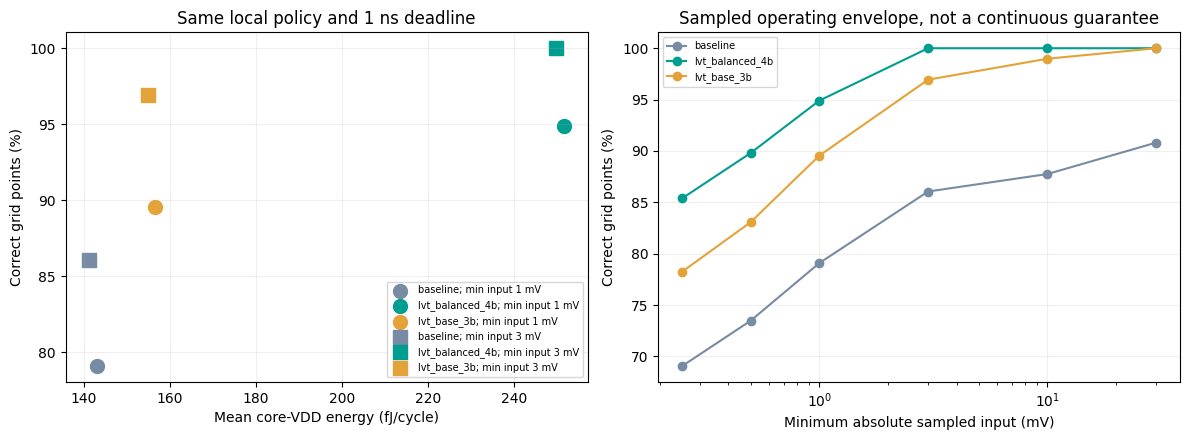

In [3]:
print("Local policy; 1 ns; sampled |input| >= 1 mV")
display(entry.summary(evidence, minimum_mv=1.0))
print("Same policy and deadline; sampled |input| >= 3 mV")
display(entry.summary(evidence, minimum_mv=3.0))
display(entry.sampled_envelope(evidence))
figure = entry.tradeoff_figure(evidence)
display(figure)
plt.close(figure)

In [4]:
import ipywidgets as widgets


def inspect_tradeoff(minimum_mv, deadline_ns):
    display(entry.summary(evidence, minimum_mv, deadline_ns))


minimum_control = widgets.SelectionSlider(
    options=[0.25, 0.5, 1.0, 3.0, 10.0, 30.0],
    value=1.0,
    description="Min |input| (mV)",
    continuous_update=False,
    style={"description_width": "initial"},
)
deadline_control = widgets.SelectionSlider(
    options=[0.25, 0.35, 0.5, 0.75, 1.0, 2.0],
    value=1.0,
    description="Deadline (ns)",
    continuous_update=False,
    style={"description_width": "initial"},
)
interactive_table = widgets.interactive_output(
    inspect_tradeoff,
    {
        "minimum_mv": minimum_control,
        "deadline_ns": deadline_control,
    },
)
display(minimum_control, deadline_control, interactive_table)

SelectionSlider(continuous_update=False, description='Min |input| (mV)', index=2, options=(0.25, 0.5, 1.0, 3.0…

SelectionSlider(continuous_update=False, description='Deadline (ns)', index=4, options=(0.25, 0.35, 0.5, 0.75,…

Output()

## 5. Numerical sensitivity is a result, not a footnote

The original 10-to-5 ps refinement exposed fourteen failed deadline
checks across seven physical points. Refinement to 0.625 ps produced
two consecutive passing halving comparisons under the unchanged
limits: identical decision/outcome, at most 1% core-energy difference
and at most 20 ps resolved-latency difference.

The finest accepted waveform replaces **every** matching policy and
deadline observation, including corrections that make the circuit
look worse. Original coarse tables and the full refinement history
remain available. No circuit, code, stimulus, deadline or frozen
candidate choice changes during this process.

The added energy-efficient control checks every nonzero input point
under both policies at 10 and 5 ps, then applies the same stricter
halving rule to sensitive points. Unresolved sensitivity blocks its
inclusion as a completed comparison.

These are numerical checks for declared observations, not proof of
stability at every continuous input, random-noise immunity or
production signoff.

In [5]:
numerical = pd.DataFrame([
    {
        "study": "original / selected",
        "initial_failed_checks":
            evidence["stress"]["initial_numerical_failures"],
        "final_failed_checks":
            evidence["stress"]["numerical_failures"],
        "refined_physical_points":
            evidence["stress"]["refined_physical_points"],
    },
    {
        "study": "post-selection lower-energy control",
        "initial_failed_checks":
            evidence["control"]["initial_failed_checks"],
        "final_failed_checks":
            evidence["control"]["final_failed_checks"],
        "refined_physical_points":
            evidence["control"]["refined_physical_points"],
    },
])
display(numerical)

,study,initial_failed_checks,final_failed_checks,refined_physical_points
0,original / selected,14,0,7
1,post-selection lower-energy control,7,0,2


## 6. Recompute metrics from actual transistor-level waveforms

The following small, hash-checked waveform set is distributed with the
entry. It is not a synthetic behavioral model. The same measurement
function used in the campaign recomputes reset validity, rail-valid
decisions, latency and full-cycle core energy.

The weak SS/low-voltage/cold condition was known during selection.
These traces illustrate mechanism; the complete condition tables
support the finite-grid comparison.

,design,input_mv,run_id,deadline_ns,decision,outcome,decision_time_ns,core_energy_fj,reset_ok,qp_at_deadline_v,qn_at_deadline_v
0,baseline,-3.0,5fce23969701f5e72e7a3401,1.0,0,unresolved,NaN,78.313915,True,1.451846,1.463549
1,baseline,3.0,487d892bb307fb0e54be2a8b,1.0,0,unresolved,NaN,78.462953,True,1.488936,1.425709
2,lvt_base_3b,-3.0,314848e1e4ffa52f7592994d,1.0,0,unresolved,NaN,108.661417,True,0.756412,0.961140
3,lvt_base_3b,3.0,4fbda9c29003a90af8587e9d,1.0,1,correct,0.904695,104.904111,True,1.552048,0.222477
4,lvt_balanced_4b,-3.0,3323b1f01e4eb2d2e9d9a1a4,1.0,-1,correct,0.585887,167.225006,True,0.072996,1.618639
5,lvt_balanced_4b,3.0,76ada1b6093541a185ade5c6,1.0,1,correct,0.840738,169.951086,True,1.604657,0.105767


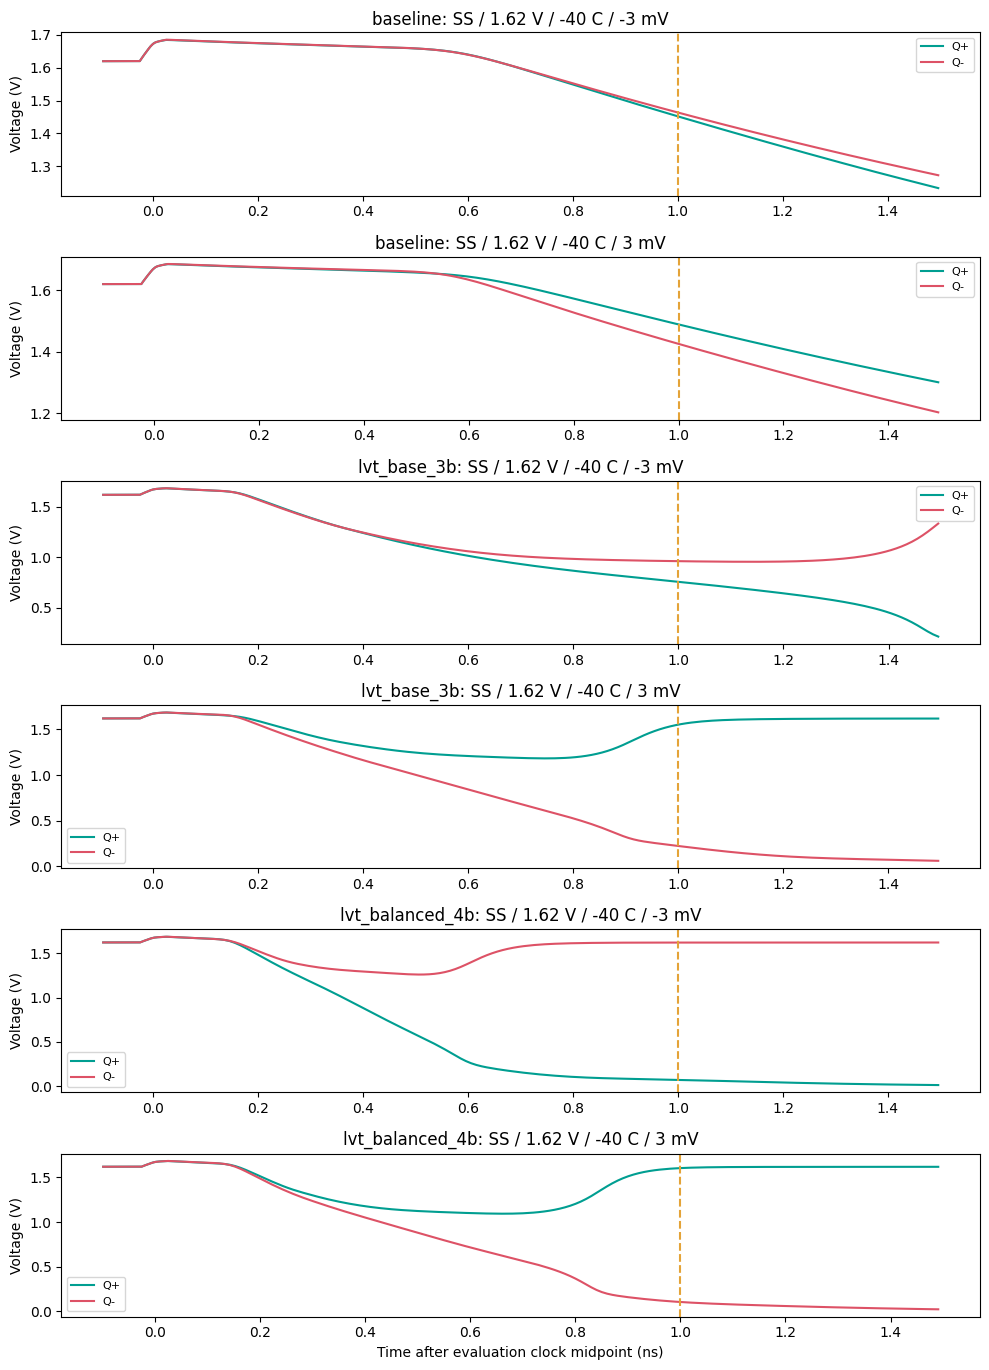

Waveform metrics recomputed from checked saved SPICE data. Set RUN_LIVE_SPICE=True for fresh transistor simulation.


In [6]:
measured, figure = entry.review_waveforms()
display(measured)
display(figure)
plt.close(figure)
if RUN_LIVE_SPICE:
    display(entry.live_spice_smoke())
else:
    print(
        "Waveform metrics recomputed from checked saved SPICE data. "
        "Set RUN_LIVE_SPICE=True for fresh transistor simulation."
    )

## 7. The input interface and calibration workload are not free

Five original/selected PVT conditions are stressed with input history,
finite source resistance and capacitance, altered common mode, and
increased output loading. The calibration code is frozen before the
interface changes. Results include the unfavorable cases: the faster
LVT path can inject larger deterministic input disturbances and does
not necessarily improve a heavily loaded interface.

The measured pin error includes settling and kickback, not random
thermal noise. These interface results apply to the original and
selected circuits; the added lower-energy control has not silently
inherited them.

Calibration workload below counts distinct simulated probes. Each
probe simulates three 10 ns cycles. This is **offline experiment
workload**, not an implemented calibration latency or total on-chip
energy. A practical system also needs reference/input generation,
switching, a controller and storage; those implementation costs
remain outside the measured core-rail energy.

In [7]:
display(entry.operating_summary(evidence))
display(entry.calibration_workload(evidence))

points  correct  \
design_name     stress                                    
baseline        ideal_reference             20       10   
                opposite_input_history      20       10   
                source_1k_20f               20        6   
                source_5k_20f               20        6   
                settling_10k_200f           20        6   
                common_mode_0p45            20       10   
                common_mode_0p60            20       10   
                output_load_20f             20        7   
lvt_balanced_4b ideal_reference             20       19   
                opposite_input_history      20       19   
                source_1k_20f               20       11   
                source_5k_20f               20       10   
                settling_10k_200f           20        8   
                common_mode_0p45            20       10   
                common_mode_0p60            20       13   
                output_load_20f             20        6   

                                        peak_differential_input_error_mv  
design_name     stress                                                    
baseline        ideal_reference                             2.602085e-15  
                opposite_input_history                      2.602085e-15  
                source_1k_20f                               5.345645e+01  
                source_5k_20f                               9.792325e+01  
                settling_10k_200f                           3.273007e+01  
                common_mode_0p45                            2.602085e-15  
                common_mode_0p60                            1.118897e-13  
                output_load_20f                             2.602085e-15  
lvt_balanced_4b ideal_reference                             2.602085e-15  
                opposite_input_history                      2.602085e-15  
                source_1k_20f                               1.320953e+02  
                source_5k_20f                               1.814124e+02  
                settling_10k_200f                           5.905097e+01  
                common_mode_0p45                            2.602085e-15  
                common_mode_0p60                            1.118897e-13  
                output_load_20f                             2.602085e-15

,minimum_distinct_probes,maximum_distinct_probes,median_distinct_probes,maximum_offline_simulated_duration_ns
design,,,,
baseline,37,139,48.0,4170
lvt_balanced_4b,53,64,64.0,1920
lvt_base_3b,37,48,48.0,1440


## 8. Reproducibility, attribution and claim boundary

`entry_tools.load_evidence()` checks source, protocol, selection and
result hashes; recomputes the explicit numerical corrections; and
rejects missing, duplicated or incorrectly represented observations.
Archived Windows-style manifest keys are resolved portably without
disabling source verification. Git attributes preserve the bytes
of hash-bound source and data files across platforms.

The default review path runs with Python 3.10 and no SPICE installation.
The optional live path uses the unmodified pinned SKY130 models and
an installed ngspice. Full reproduction is available through the
source CLI and the explicit full-campaign switch; runtime, tool
versions and the distinction from saved results are documented.

**Supported:** deterministic schematic behavior under the declared
stimuli; a bounded design-space comparison; measured core-rail energy;
an inspectable educational workflow.

**Not supported:** a new topology, global optimum, fabrication-ready
layout, silicon performance, yield, noise-error probability, total
system power, or superiority over unmatched published circuits.
No "IEEE certification" or award is implied.

### References

1. B. Razavi, “The StrongARM Latch [A Circuit for All Seasons],”
   *IEEE Solid-State Circuits Magazine*, vol. 7, no. 2, pp. 12–17,
   2015. DOI: [10.1109/MSSC.2015.2418155](https://doi.org/10.1109/MSSC.2015.2418155).
2. S. Li, Z. Xu and T. Iizuka, “Analysis of strong-arm comparator with
   auxiliary pair for offset calibration,” *Analog Integrated Circuits
   and Signal Processing*, vol. 110, pp. 535–546, 2022.
   DOI: [10.1007/s10470-022-01992-6](https://doi.org/10.1007/s10470-022-01992-6).
3. [Official SKY130 primitive models](https://github.com/google/skywater-pdk-libs-sky130_fd_pr),
   revision `f62031a1be9aefe902d6d54cddd6f59b57627436`.
   Original Apache-2.0 notices are retained.
4. [Open SKY130/GF180 comparator optimization research](https://github.com/ChrisZonghaoLi/sky130_comparator_rl)
   and [an existing SKY130/LVT comparator example](https://github.com/edonD/sky130-comparator).
   Related ideas are credited; their code, figures, performance
   claims and statistical assumptions are not this study's evidence.
5. [ngspice](https://ngspice.sourceforge.io/) and
   [Code-a-Chip rules](https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io).

**AI-assistance disclosure.** GitHub Copilot assisted code, experiment
automation and documentation. Wei-Lun Hsu is responsible for reviewing,
explaining and defending the submitted work. This assistance is not
an assertion that a particular publication or award policy has been
waived. Original code and prose are MIT licensed; third-party models
and tools retain their own licenses.